In [ ]:
# --- Setup: make the `ecp` support package available -----------------
# Colab opens a single notebook and installs nothing, so fetch `ecp` from
# the public repo if it isn't importable yet. On Binder/local it is already
# installed, so this cell is a fast no-op there.
try:
    import ecp  # noqa: F401
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "git+https://github.com/ramador09/elementary-computational-physics-public@main"],
        check=True,
    )


# 4.2 The Formation of Molecular Oxygen

<!-- One H1 per notebook ("# <number> <Title>"): it sets the sidebar entry,
     breadcrumb, browser tab, and search result. The branded banner below is
     generated by the shared `ecp` package. -->

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Volume IV — Electronic Structure",
    number="4.2",
    title="The Formation of Molecular Oxygen",
    blurb="Why oxygen is magnetic, read from a real CP2K calculation: the electron "
    "density and the charge that builds up on bonding, the molecular orbitals "
    "themselves, and the spin-split eigenvalues that put two unpaired electrons "
    "in the π* orbitals and make O₂ a triplet.",
    difficulty="intermediate",
    estimate="90–120 min",
    source="FS 2023 · Lecture 6 (molecular orbital theory)",
)

<ECP header: 2847 chars of HTML>

## Notebook overview

This exercise examines the formation of **triplet oxygen**, the most stable and
most common form of O₂. Triplet oxygen has two electrons in its two **degenerate**
$\pi^*$ orbitals, and according to **Hund's rules** the configuration with those
two electrons unpaired, with parallel spins, is the one nature chooses: the total
spin is $S=1$, a triplet, and the molecule is magnetic. A simple Lewis structure,
with every electron paired, misses this entirely. Molecular-orbital theory does
not, and it is the molecular-orbital picture we build and verify here.

We work from a real Hartree-Fock calculation. The course ran O₂ in **CP2K**,
printing the electron density and the frontier molecular orbitals to cube files,
and we use that genuine output: we visualise the electron density, compute the
**density difference** that shows where charge moves when the bond forms, look at
the **molecular orbitals** one by one, repeat for the single oxygen **atom**, and
finally read the **spin-split eigenvalues** from the run to build the
molecular-orbital schema and explain the paramagnetism.

> **Provenance.** This notebook develops **Lecture 6** of the course (the formation
> of molecular oxygen via molecular-orbital theory), an exercise **designed by the
> author (Raymond Amador)**, and follows its assignments.
> The cube visualisations and eigenvalues are the *real* CP2K output of the
> exercise (an anonymised course run), with the volumetric cubes downsampled for
> size; the input deck shown is the course's own. The full course credit is in the
> footer.

> **Reading a validation.** Each task closes with a check against an independent
> fact: electron conservation, the electron count of the molecule versus the atom,
> the spin imbalance that defines the triplet. A ✗ flags a mismatch to track down,
> not a verdict; a ✓ is strong evidence, not proof.

> **Scope.** Cube data are visualised as isosurfaces; energies are converted from
> Hartree to eV. For the chemistry see Atkins & Friedman {cite}`atkins-mqm`; the
> calculations were run in CP2K; the cube format stores a scalar field on a 3-D
> grid.

## Theory in brief

### From atomic orbitals to molecular orbitals

When two atoms bond, their atomic orbitals combine into **molecular orbitals**: an
in-phase **bonding** combination, lower in energy, with charge piled up between the
nuclei, and an out-of-phase **antibonding** combination (starred), higher in
energy, with a node between them. For O₂ the valence $2s$ and $2p$ orbitals build
the set

```{math}
:label: eq-mo-set
\sigma_{2s},\ \sigma_{2s}^{*},\ \sigma_{2p},\ \pi_{2p}\,(\times 2),\ \pi_{2p}^{*}\,(\times 2),\ \sigma_{2p}^{*},
```

the two $\pi_{2p}$ and the two $\pi_{2p}^{*}$ each a degenerate pair. Oxygen brings
six valence electrons each, twelve in all, which fill the diagram from the bottom
and leave the last **two electrons in the degenerate $\pi^*$ pair**.

### Spin, and the triplet

Two electrons in two equal orbitals follow **Hund's rule**: one in each, spins
parallel, because same-spin electrons keep apart (Pauli) and so repel less. The
spins do not cancel ($S=1$), the molecule is a **triplet**, and it is
**paramagnetic**, with a spin-only moment $\mu=\sqrt{n(n+2)}\,\mu_B$ for $n$
unpaired electrons. A spin-polarised calculation makes this concrete by solving for
spin-up ($\alpha$) and spin-down ($\beta$) electrons separately: the two unpaired
$\pi^*$ electrons are both $\alpha$, so the molecule has **two more $\alpha$
electrons than $\beta$**, the numerical fingerprint of the triplet that we will
read straight off the eigenvalues.

### What the calculation gives us

Hartree-Fock in CP2K returns the electron density $\rho(\mathbf r)$,
the individual molecular orbitals $\psi_i(\mathbf r)$, and their
energies $\varepsilon_i$, written to **cube files** (a scalar on a 3-D grid) and to
the output log. Subtracting the densities of the separated atoms from the molecule
gives the **density difference**, a direct picture of the bond; the orbital cubes
show the $\sigma$ and $\pi$ shapes themselves; and the eigenvalues, split by spin,
build the molecular-orbital schema.

---
## Setup

The Setup below holds this notebook's data and instruments — nothing you are asked
to build. It is collapsed so the building stays yours; expand it whenever you want
the details.

<!-- setup-policy: v2 -->

In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scipy.ndimage as ndi
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from skimage.measure import marching_cubes

from ecp import validate

INK, AMBER, SOFT = "#16213e", "#c0851a", "#46506b"
from scipy.constants import physical_constants

# data: unit conversions for the committed CP2K output. The cube reader and the
# isosurface plotter below are instruments — parsing a volumetric file format and
# drawing a contour are not the lesson of a molecular-orbital notebook. The model
# that PREDICTS what those files show is the lesson, and it is built in Exercise 7.
HARTREE_EV = physical_constants["Hartree energy in eV"][0]
BOHR_A = physical_constants["Bohr radius"][0] * 1e10  # Bohr radius in Å


def data_file(name):
    """Locate a shipped data file, from the repo root (CI) or the notebook dir (Colab).

    Parameters
    ----------
    name : str
        File name (or relative path) under a ``data`` directory.

    Returns
    -------
    str
        The first existing path found.

    Raises
    ------
    FileNotFoundError
        If the file is not found under any candidate base.
    """
    for base in ("data", os.path.join("notebooks", "04-electronic-structure", "data")):
        path = os.path.join(base, name)
        if os.path.exists(path):
            return path
    raise FileNotFoundError(name)


def read_cube(name):
    """Parse a Gaussian cube file.

    Parameters
    ----------
    name : str
        Cube file name.

    Returns
    -------
    dict
        Keys: ``label``, ``origin`` (3,), ``vec`` (3, 3) voxel vectors, ``atoms``
        (n_at, 3) coordinates, ``data`` the 3-D scalar grid, and ``dV`` the
        voxel volume.
    """
    lines = open(data_file(name)).read().splitlines()
    label = lines[0].strip()
    n_at = int(lines[2].split()[0])
    origin = np.array(lines[2].split()[1:4], float)
    vec = np.array([[float(x) for x in lines[3 + i].split()[1:4]] for i in range(3)])
    ng = [int(lines[3 + i].split()[0]) for i in range(3)]
    atoms = np.array(
        [[float(x) for x in lines[6 + i].split()[2:5]] for i in range(n_at)]
    )
    data = np.array(" ".join(lines[6 + n_at :]).split(), float).reshape(ng)
    return dict(
        label=label,
        origin=origin,
        vec=vec,
        atoms=atoms,
        data=data,
        dV=abs(np.linalg.det(vec)),
    )


def add_isosurfaces(ax, cube, levels, upsample=3, alpha=1.0):
    """Draw a cube file's isosurfaces on a 3-D axis, lit and depth-sorted.

    The committed cubes are downsampled to keep the repository lean, and a
    marching-cubes mesh built directly on that coarse grid renders as large flat
    facets. The field itself is smooth, so a cubic-spline interpolation of the
    grid (display only — every integral in this notebook is computed on the raw
    committed data) recovers a mesh close to what the full-resolution cube would
    give. All levels go into a single collection so matplotlib's painter sort
    sees every triangle at once, and faces are shaded by their normals against a
    fixed light, which is what makes the lobes read as three-dimensional.

    Parameters
    ----------
    ax : mpl_toolkits.mplot3d.axes3d.Axes3D
        The target 3-D axis.
    cube : dict
        A parsed cube from ``read_cube``.
    levels : list of tuple
        ``(isovalue, colour)`` pairs (amber for positive lobes, navy for negative).
    upsample : int, optional
        Spline upsampling factor for the display mesh (default 3).
    alpha : float, optional
        Surface opacity. Opaque suits well-separated orbital lobes; a density
        that encloses its nucleus, or a difference density whose two signs
        interpenetrate, needs some translucency to show what is inside.

    Returns
    -------
    numpy.ndarray
        All surface vertices, shape (n, 3) — the caller frames the view with them.
    """
    d, vec, origin = cube["data"], cube["vec"], cube["origin"]
    spacing = (vec[0, 0], vec[1, 1], vec[2, 2])
    dz = ndi.zoom(d, upsample, order=3)
    sp = tuple(s * (n - 1) / (nz - 1) for s, n, nz in zip(spacing, d.shape, dz.shape))
    light = np.array([0.45, 0.3, 0.85])
    light = light / np.linalg.norm(light)
    tris, cols, all_verts = [], [], []
    for lvl, col in levels:
        if not (dz.min() < lvl < dz.max()):
            continue
        verts, faces, _, _ = marching_cubes(dz, level=lvl, spacing=sp)
        verts = verts + origin
        tri = verts[faces]
        normal = np.cross(tri[:, 1] - tri[:, 0], tri[:, 2] - tri[:, 0])
        normal = normal / (np.linalg.norm(normal, axis=1, keepdims=True) + 1e-30)
        # two-sided lighting: a closed lobe shows both face orientations
        shade = 0.62 + 0.38 * np.abs(normal @ light)
        base = np.array(mcolors.to_rgb(col))
        rgb = np.clip(shade[:, None] * base[None, :], 0.0, 1.0)
        tris.append(tri)
        cols.append(np.concatenate([rgb, np.full((len(rgb), 1), alpha)], axis=1))
        all_verts.append(verts)
    if tris:
        coll = Poly3DCollection(
            np.concatenate(tris), facecolors=np.concatenate(cols), edgecolor="none"
        )
        ax.add_collection3d(coll)
    return np.concatenate(all_verts) if all_verts else np.zeros((0, 3))


def frame_molecule(ax, verts, atoms, title):
    """Frame a 3-D axis tightly around a rendered molecule.

    The default framing shows the whole simulation cell, most of which is vacuum,
    so the molecule shrinks into a corner of an empty box. Fitting the limits to
    the surface and the atoms — with the same span on every axis, so nothing is
    distorted — is what makes the orbital fill the figure.

    Parameters
    ----------
    ax : mpl_toolkits.mplot3d.axes3d.Axes3D
        The target 3-D axis.
    verts : numpy.ndarray
        Surface vertices from :func:`add_isosurfaces`, shape (n, 3).
    atoms : numpy.ndarray
        Atom positions, shape (n_atoms, 3).
    title : str
        Panel title.
    """
    ax.scatter(
        *atoms.T, s=110, color="#3a3a3a", edgecolor="white", lw=1.0, depthshade=False
    )
    pts = np.vstack([verts, atoms]) if len(verts) else atoms
    centre = 0.5 * (pts.min(axis=0) + pts.max(axis=0))
    # Per-axis limits, with the box aspect set to the same ratios: units stay
    # equal on screen (nothing is distorted), but an elongated molecule gets an
    # elongated box instead of rattling around inside a cube of vacuum.
    span = pts.max(axis=0) - pts.min(axis=0)
    half = 0.56 * np.maximum(span, 0.45 * span.max())
    ax.set_xlim(centre[0] - half[0], centre[0] + half[0])
    ax.set_ylim(centre[1] - half[1], centre[1] + half[1])
    ax.set_zlim(centre[2] - half[2], centre[2] + half[2])
    ax.set_box_aspect(tuple(half))
    # The cubes put the molecular axis along z; rolling the camera by 90 degrees
    # lays it horizontal on screen, the orientation every textbook MO diagram
    # uses, and the one that actually fills a wide panel.
    ax.view_init(elev=12, azim=-58, roll=90)
    ax.set_axis_off()
    ax.set_title(title)


def show_isosurface(cube, levels, title, alpha=1.0):
    """Render cube isosurfaces with the atoms marked, on a new 3-D figure.

    Parameters
    ----------
    cube : dict
        A parsed cube from ``read_cube``.
    levels : list of tuple
        ``(isovalue, colour)`` pairs (amber for positive lobes, navy for negative).
    title : str
        Figure title.

    Returns
    -------
    matplotlib.figure.Figure
        The figure with the rendered isosurface(s).
    """
    fig = plt.figure(figsize=(4.8, 4.5))
    ax = fig.add_subplot(projection="3d")
    verts = add_isosurfaces(ax, cube, levels, alpha=alpha)
    frame_molecule(ax, verts, cube["atoms"], title)
    fig.subplots_adjust(left=0.0, right=1.0, bottom=0.0, top=0.92)
    return fig

## Exercise 1 — The CP2K input file

Every calculation starts from its input deck. The course's `triplet.inp` is a
spin-polarised (`LSD`) Hartree-Fock run with the **triplet** imposed through
`MULTIPLICITY 3` (so $2S+1=3$, $S=1$), and a `&PRINT` block that writes the cube
files we will use:

```text
&DFT
  LSD                       ! spin-polarised: separate alpha and beta densities
  MULTIPLICITY 3            ! triplet (two unpaired electrons)
  &PRINT
    &E_DENSITY_CUBE         ! write the electron density to a cube file
    &END E_DENSITY_CUBE
    &MO_CUBES               ! write molecular-orbital cubes
      NHOMO -1              ! ... every occupied MO (HOMO down)
      NLUMO 3               ! ... and three lowest unoccupied
    &END MO_CUBES
  &END PRINT
&END DFT
```

It ships with this notebook: {download}`triplet.inp <data/o2-triplet.inp>`. Those
two print directives are exactly what generate the density and orbital cubes the
rest of the exercise visualises.

**Part a)** Read the deck.

**Part b)** Confirm it requests a triplet and the cube
output.

In [3]:
# (solution hidden on the public site)


MULTIPLICITY = 3  ->  S = 1 (triplet); writes density cube: True


### Validation 1 — the deck describes a triplet with cube output

The input must specify multiplicity 3 (a spin-1 triplet) and request the electron
density cube, the two ingredients the rest of the exercise depends on.

In [4]:
validate.check(
    multiplicity == 3 and spin_S == 1 and writes_density,
    "the input deck requests a triplet (multiplicity 3) and writes the density cube",
    f"MULTIPLICITY = {multiplicity} (S = {spin_S:.0f}), E_DENSITY_CUBE = {writes_density}",
)

✓  the input deck requests a triplet (multiplicity 3) and writes the density cube   [MULTIPLICITY = 3 (S = 1), E_DENSITY_CUBE = True]


True

## Exercise 2 — The electron density

Once the job finishes it writes the electron density to a cube file: the scalar
$\rho(\mathbf r)$ on a 3-D grid. We render it as an **isosurface**, the surface on
which the density takes a chosen value, with the two oxygen nuclei marked. The
density is a single smooth cloud enveloping both atoms, the hallmark of a bound
molecule rather than two separate ones.

**Part a)** Read and render the O₂ electron-density cube.

**Part b)** Confirm it is
a physical density.

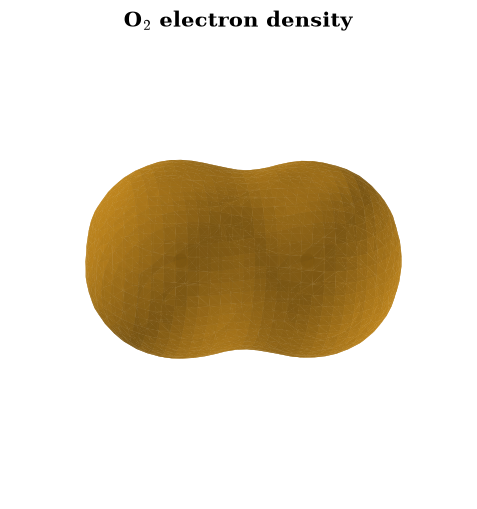

min ρ = -8.76e-06; ∫ρ d³r = 11.885 (the 12 GTH valence electrons)


In [5]:
# (solution hidden on the public site)


### Validation 2 — a physical electron density

A real electron density is non-negative everywhere. (The integral under-counts
here only because the cube was downsampled for size, blurring the sharp peaks at
the nuclei; we check the electron *count* properly in Exercises 3 and 5.)

In [6]:
validate.check(
    o2_density["data"].min() > -1e-4,
    "the electron density is non-negative everywhere (to numerical noise)",
    f"min ρ = {o2_density['data'].min():.2e}, max ρ = {o2_density['data'].max():.3f}",
)

✓  the electron density is non-negative everywhere (to numerical noise)   [min ρ = -8.76e-06, max ρ = 0.946]


True

## Exercise 3 — The density difference (Assignment 1)

The total density is striking but not the most informative quantity; the
*difference* is. Subtracting the densities of the two separate oxygen atoms from
the molecule's density, $\Delta\rho=\rho_{\mathrm{O_2}}-\rho_{\mathrm{O}}-\rho_{\mathrm{O}}$,
isolates exactly the charge that **rearranges when the bond forms**: amber where
electrons accumulate, navy where they are depleted. Because the molecule and the
two atoms hold the same total number of electrons, the difference must integrate to
zero, which is our check.

**Part a)** Render the density-difference cube.

**Part b)** Confirm electron number
is conserved.

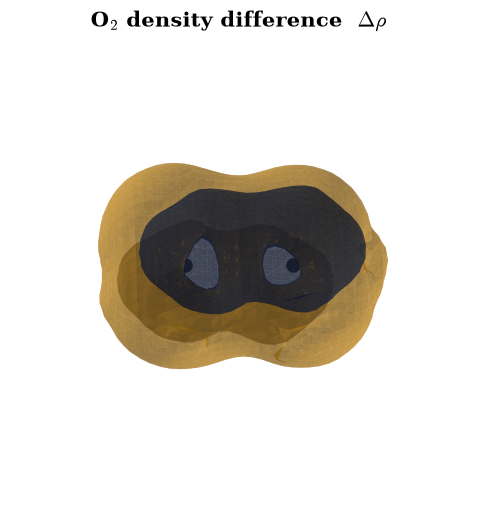

In [7]:
# (solution hidden on the public site)


### Validation 3 — electron conservation

Forming a bond moves charge around but neither creates nor destroys it, so the
density difference must integrate to ≈ 0.

In [8]:
validate.close(
    delta_n,
    0.0,
    "the density difference integrates to zero (electrons conserved)",
    atol=0.05,
)

✓  the density difference integrates to zero (electrons conserved)   [got -0.0194206 vs expected 0 (rtol=1e-06, atol=0.05)]


True

## Exercise 4 — The molecular orbitals (Assignment 2)

The calculation also prints individual **molecular orbitals**. Their cube file
names encode which orbital each is: a comment line reads `WAVEFUNCTION i spin s
i.e. HOMO - n`, so the highest occupied (the HOMO) is $n=0$, the one below it
$n=1$, and so on. Decoding those tags identifies three valence orbitals worth
seeing: a bonding $\pi_{2p}$, a bonding $\sigma_{2p}$, and the **antibonding
$\pi^*$** that is the HOMO and holds the two unpaired electrons. Bonding orbitals
concentrate charge between the nuclei; the antibonding $\pi^*$ has a node there,
visible as the change of lobe colour across the bond.

**Part a)** Render the three orbitals.

**Part b)** Confirm they are proper
(normalised) one-electron orbitals.

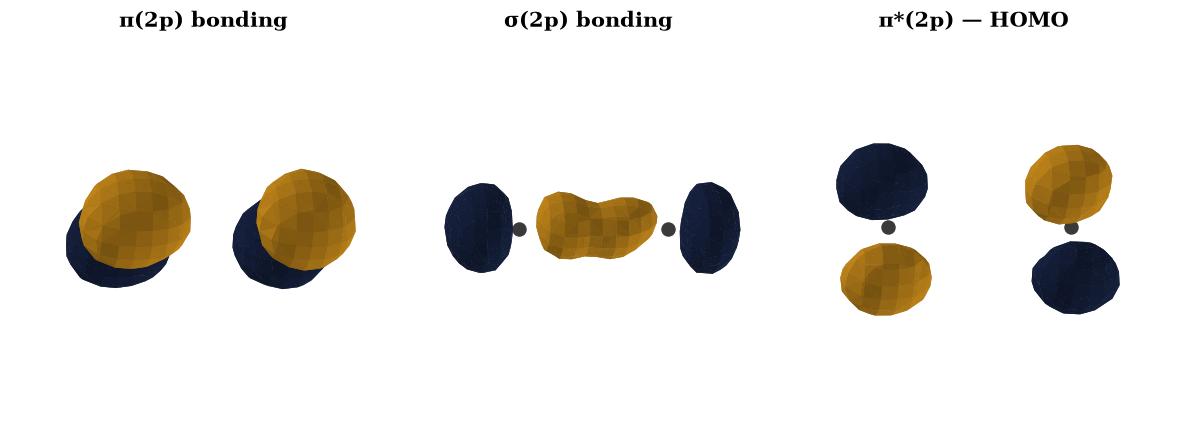

∫|ψ|² d³r = 0.9870, 0.9994, 1.0200


In [9]:
# (solution hidden on the public site)


### Validation 4 — proper one-electron orbitals

Each Hartree-Fock orbital is normalised, so $\int|\psi|^2\,dV$ must be the same for all
three (the same value the downsampling preserves), confirming they are genuine
single-electron molecular orbitals.

In [10]:
validate.close(
    np.array(norms),
    norms[0],
    "the three orbitals share one normalisation (∫|ψ|² equal)",
    rtol=0.05,
)

✓  the three orbitals share one normalisation (∫|ψ|² equal)   [max|Δ| = 0.0329698 (rtol=0.05, atol=1e-09)]


True

## Exercise 5 — The oxygen atom (Assignment 3)

The same calculation for a single oxygen atom gives a reference. Its density is one
spherical-ish cloud about a single nucleus, and crucially it holds **half** the
electrons of the molecule. Comparing the integrated densities is a clean,
downsampling-proof check: the molecule must contain exactly twice the atom's
electrons — 12 valence electrons against 6, since the GTH pseudopotentials fold
each 1s core into the potential and the cubes therefore hold valence density
only — so the *ratio* of the integrals is 2, with the per-cent-level shortfall
of each absolute integral being the coarse grid's quadrature error.

**Part a)** Render the O-atom density.

**Part b)** Confirm the molecule has twice
the atom's electrons.

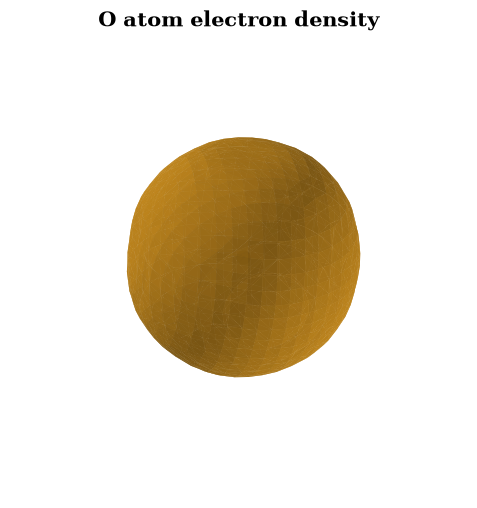

∫ρ(O₂) = 11.89, ∫ρ(O) = 5.95 valence electrons  ->  ratio 1.998  (12 vs 6; the 1s cores live in the pseudopotential)


In [11]:
# (solution hidden on the public site)


### Validation 5 — the molecule has twice the atom's electrons

The ratio of the integrated densities must be 2: the molecule is two oxygen atoms'
worth of electrons.

In [12]:
validate.close(
    ratio,
    2.0,
    "O₂ holds twice the electrons of an O atom (integral ratio = 2)",
    rtol=0.03,
)

✓  O₂ holds twice the electrons of an O atom (integral ratio = 2)   [got 1.99767 vs expected 2 (rtol=0.03, atol=1e-09)]


True

## Exercise 6 — The eigenvalues and the molecular-orbital schema (Assignment 4)

Finally we read the energies. The output lists the occupied eigenvalues separately
for spin-up ($\alpha$) and spin-down ($\beta$), and the asymmetry is the whole
story: there are **nine occupied $\alpha$ orbitals but only seven occupied
$\beta$**, a difference of two. Those two extra spin-up electrons sit in the
degenerate $\pi^*$ pair with no spin-down partners, exactly the unpaired electrons
of the triplet. Dropping the two core $1s$ states, we plot the valence levels at
their real energies and fill them with $\alpha$ (up) and $\beta$ (down) electrons,
reproducing the molecular-orbital schema from the calculation itself.

One feature departs from the idealised diagram of {eq}`eq-mo-set`: in the spin-up
($\alpha$) channel the bonding $\pi_{2p}$ pair sits just *below* $\sigma_{2p}$,
because the two unpaired $\alpha$ electrons in $\pi^*$ exchange-stabilise the
same-spin bonding $\alpha\,\pi_{2p}$. The spin-down ($\beta$) channel, with $\pi^*$
empty, keeps the textbook $\sigma_{2p}$-below-$\pi_{2p}$ order. Either way the last
two electrons occupy the $\pi^*$ pair, so the triplet conclusion is unchanged.

**Part a)** Build the schema from the real eigenvalues.

**Part b)** Confirm the
spin imbalance, and the paramagnetic moment it implies.

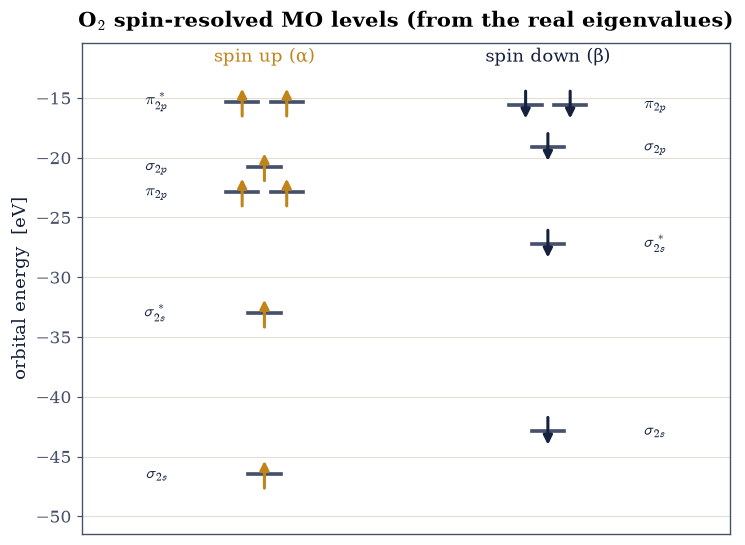

occupied: 9 α, 7 β  ->  2 unpaired electrons; μ = 2.83 μ_B


In [13]:
# (solution hidden on the public site)


### Validation 6 — two unpaired electrons, a paramagnetic triplet

The spin-up/spin-down imbalance must be exactly two unpaired electrons, giving spin
$S=1$ and the spin-only moment $\mu=\sqrt{8}\approx2.83\,\mu_B$: O₂ is a
paramagnetic triplet, the result a Lewis structure cannot give.

In [14]:
validate.check(
    n_unpaired == 2 and abs(mu - np.sqrt(8)) < 1e-6,
    "O₂ has two unpaired electrons (S=1) and a non-zero magnetic moment",
    f"{n_unpaired} unpaired → μ = {mu:.2f} μ_B",
)

✓  O₂ has two unpaired electrons (S=1) and a non-zero magnetic moment   [2 unpaired → μ = 2.83 μ_B]


True

## Exercise 7 — The model that predicts the triplet

Everything so far has been *read* from a calculation. That is the honest way to
treat density-functional theory, which no notebook can reimplement — but it leaves
a question standing. Did we need the calculation to know O₂ is a triplet?

We did not, and the model that gets there is old enough to predate quantum
chemistry software entirely. Take one $2s$ and three $2p$ orbitals on each atom and
let each pair combine into a bonding and an antibonding molecular orbital. For two
atomic orbitals of the same energy $\alpha$ coupled by a resonance integral $\beta$
with overlap $S$, the secular problem gives

```{math}
:label: eq-lcao-two-centre
E_{\pm} = \frac{\alpha \pm \beta}{1 \pm S},
```

with $\beta<0$, so $E_+$ lies below $\alpha$ and $E_-$ above it. The overlap in the
denominator is what makes the antibonding orbital rise *more* than the bonding one
falls, which is why filling both is worse than filling neither. Two $p$ orbitals
pointing at each other overlap head-on and split strongly ($\sigma$); the two
perpendicular pairs overlap sideways and split weakly ($\pi$), and stay degenerate
with each other by symmetry.

Fill the resulting ladder with O₂'s twelve valence electrons under the Aufbau
principle and Hund's rule, and the last two land in the degenerate $\pi^*$ pair with
parallel spins. That is the triplet — obtained from symmetry, counting and one
$2\times2$ secular equation, with no self-consistent field anywhere.

**Part a)** Implement `two_centre(alpha, beta, overlap)` returning the bonding and
antibonding pair of {eq}`eq-lcao-two-centre`. Confirm on the way that the
antibonding orbital is destabilised by more than the bonding one is stabilised,
which is the whole reason a filled antibonding level cancels more than a bond.
**Write this one yourself** — the implementation is the lesson.

**Part b)** Assemble the valence ladder: $\sigma_{2s}$, $\sigma^*_{2s}$ from the
$2s$ pair, and $\sigma_{2p}$, $\pi_{2p}$ (twofold), $\pi^*_{2p}$ (twofold),
$\sigma^*_{2p}$ from the $2p$ set. Fill twelve electrons with `numpy` bookkeeping,
applying Hund's rule within the degenerate $\pi^*$ level: singly occupy both before
pairing either.

**Part c)** Read off the bond order $(n_{\rm bonding}-n_{\rm antibonding})/2$ and
the number of unpaired electrons, and compare both with the calculation. The model
owes nothing to the CP2K output, so agreement here is a genuine cross-check of the
picture against the machine.

filled levels: [('sigma_2s', 2), ('sigma*_2s', 2), ('sigma_2p', 2), ('pi_2p', 4), ('pi*_2p', 2)]
bonding 8, antibonding 4  ->  bond order 2.0
unpaired electrons predicted by LCAO+Hund: 2
unpaired electrons measured from the CP2K output (Exercise 6): 2


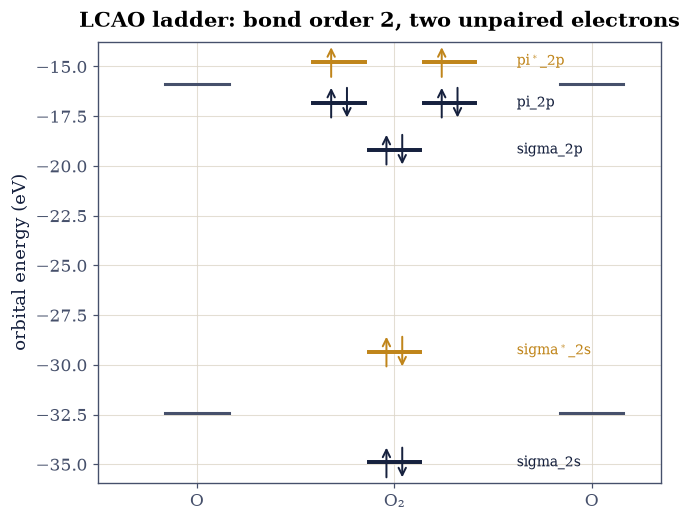

In [15]:
# (solution hidden on the public site)


### Validation 7 — the picture agrees with the machine

The model is checked on the two things it actually claims, both of them integers
that follow from symmetry and counting rather than from the illustrative parameter
values: a bond order of two, and two unpaired electrons. The second is then set
against the spin imbalance measured from the committed CP2K eigenvalues in Exercise
6 — two calculations with nothing in common but the physics.

In [16]:
validate.check(
    two_centre(A2P, B_PI, S_OVERLAP)[1] - A2P
    > A2P - two_centre(A2P, B_PI, S_OVERLAP)[0],
    "the antibonding level rises further than the bonding level falls, the "
    "asymmetry the overlap denominator of eq-lcao-two-centre puts there",
    f"up {two_centre(A2P, B_PI, S_OVERLAP)[1] - A2P:+.3f} eV vs "
    f"down {two_centre(A2P, B_PI, S_OVERLAP)[0] - A2P:+.3f} eV",
)
validate.close(
    bond_order,
    2.0,
    "filling the LCAO ladder with 12 valence electrons gives bond order 2, the "
    "double bond of O₂",
    rtol=1e-12,
)
validate.check(
    unpaired == 2 and unpaired == n_unpaired,
    "and Hund's rule in the degenerate pi* pair predicts exactly the two unpaired "
    "electrons the density-functional calculation reports: the picture and the "
    "machine agree",
    f"LCAO predicts {unpaired}, CP2K output gives {n_unpaired}",
)

✓  the antibonding level rises further than the bonding level falls, the asymmetry the overlap denominator of eq-lcao-two-centre puts there   [up +1.122 eV vs down -0.918 eV]
✓  filling the LCAO ladder with 12 valence electrons gives bond order 2, the double bond of O₂   [got 2 vs expected 2 (rtol=1e-12, atol=1e-09)]
✓  and Hund's rule in the degenerate pi* pair predicts exactly the two unpaired electrons the density-functional calculation reports: the picture and the machine agree   [LCAO predicts 2, CP2K output gives 2]


True

## Exercise 8 — The deck reproduced: unrestricted Hartree–Fock, live

Everything above analyses the committed CP2K output. This exercise closes the
loop by *running the deck's calculation*, here and now: the committed input
specified `XC_FUNCTIONAL NONE` with `MULTIPLICITY 3` and `LSD` — unrestricted
Hartree–Fock with two more α than β electrons — and PySCF can do exactly that
in under a second. Two runs, triplet and singlet, and three verdicts to read.

First the ordering: the triplet must fall below the singlet, Hund's rule as an
energy difference rather than a slogan — with the standing caveat that the
*singlet* of O$_2$ is genuinely multireference, so its single-determinant
energy is only good enough to order, never to quote. Second, the spin: an
unrestricted determinant is not an eigenstate of $\hat S^2$, and the measured
$\langle S^2\rangle$ lands *slightly above* the exact $S(S+1) = 2$ — that
excess is **spin contamination**, the price UHF pays for letting α and β
orbitals differ, and reading its size is part of reading any unrestricted
calculation. Third, the pattern: the α/β occupation structure must match the
committed CP2K eigenvalue schema of Exercise 6 — nine α against seven β
valence electrons, with the β LUMO a *degenerate* π$^\ast$ pair, the two holes
Hund's rule carved out.

**Part a)** Run UHF for the triplet and the singlet at the experimental bond
length and report total energies and $\langle S^2\rangle$.

**Part b)** Read the three verdicts: ordering, contamination, and the α/β
level pattern against the committed CP2K schema.

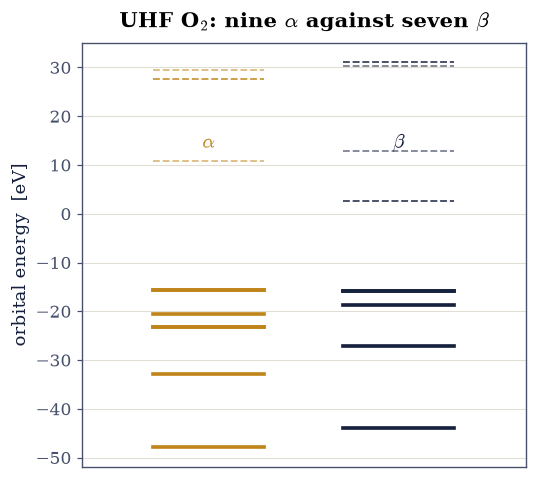

E(triplet) = -149.545575 Ha, E(singlet) = -149.513527 Ha  ->  triplet lower by 0.87 eV
<S^2> = 2.0334 (exact S(S+1) = 2; the excess 0.0334 is UHF spin contamination)
occupations: 9 alpha / 7 beta; beta LUMO pair split 3.84e-15 Ha -- the two degenerate pi* holes of Exercise 6's committed schema


In [17]:
# (solution hidden on the public site)


### Validation 8 — the deck's physics, recomputed and re-verdicted

Four checks. Both SCF runs must have converged, or nothing downstream means
anything. The triplet must lie below the singlet — Hund's rule as an energy
difference, ordering only, the singlet being multireference. The spin
contamination must be positive and small: $\langle S^2\rangle$ just above 2 is
the signature of a mildly spin-broken unrestricted triplet, and a large excess
would indict the calculation. And the α/β pattern must reproduce the committed
CP2K schema — two more α than β, with the empty β π$^\ast$ pair degenerate to
machine precision, since that degeneracy is symmetry rather than fitting.

In [18]:
validate.check(
    bool(mf_triplet.converged) and bool(mf_singlet.converged),
    "both unrestricted SCF runs converged",
    f"triplet {mf_triplet.converged}, singlet {mf_singlet.converged}",
)
validate.check(
    gap_ts > 0.5,
    "the triplet lies well below the single-determinant singlet: Hund's rule "
    "as a computed energy difference, ordering gated and the singlet's "
    "multireference character left honestly unquoted",
    f"triplet below by {gap_ts:.2f} eV",
)
validate.check(
    0.0 < s2_triplet - 2.0 < 0.1,
    "the spin contamination is positive and small: <S^2> sits just above the "
    "exact 2, the fingerprint of a mildly spin-broken UHF triplet",
    f"<S^2> - 2 = {s2_triplet - 2.0:.4f}",
)
validate.check(
    (n_alpha - n_beta) == 2 and beta_lumo_split < 1e-6,
    "and the alpha/beta structure reproduces the committed CP2K schema: two "
    "more alpha electrons than beta, and the beta LUMO a pi* pair degenerate "
    "to machine precision -- the two holes Hund's rule carved",
    f"{n_alpha} alpha / {n_beta} beta; beta-LUMO split {beta_lumo_split:.1e} Ha",
)

✓  both unrestricted SCF runs converged   [triplet True, singlet True]
✓  the triplet lies well below the single-determinant singlet: Hund's rule as a computed energy difference, ordering gated and the singlet's multireference character left honestly unquoted   [triplet below by 0.87 eV]
✓  the spin contamination is positive and small: <S^2> sits just above the exact 2, the fingerprint of a mildly spin-broken UHF triplet   [<S^2> - 2 = 0.0334]
✓  and the alpha/beta structure reproduces the committed CP2K schema: two more alpha electrons than beta, and the beta LUMO a pi* pair degenerate to machine precision -- the two holes Hund's rule carved   [9 alpha / 7 beta; beta-LUMO split 3.8e-15 Ha]


True

## Notebook summary

We worked the real CP2K calculation of molecular oxygen end to end: the electron
density, the bonding charge build-up in the density difference (which integrates to
zero, conserving electrons), the bonding $\pi$ and $\sigma$ and antibonding $\pi^*$
molecular orbitals, and the single oxygen atom for comparison. The spin-resolved
eigenvalues told the central story: nine occupied $\alpha$ orbitals against seven
$\beta$, the difference of two being the unpaired electrons in the degenerate
$\pi^*$ pair. That is why ground-state O$_2$ is a paramagnetic triplet, the result
a Lewis structure cannot give.

## Outlook

- **The spin density.** The calculation also wrote a spin-density cube,
  $\rho_\alpha-\rho_\beta$; rendering it shows the unpaired-electron density sitting
  exactly in the $\pi^*$ orbitals.
- **Singlet oxygen.** Pairing the two $\pi^*$ electrons gives the reactive ¹Δg
  state, 0.98 eV higher; it is multireference, so a single-determinant method
  describes it only crudely.
- **The second row.** B₂ is paramagnetic for the same reason, while C₂ and N₂ are
  not; the $\sigma_{2p}/\pi_{2p}$ ordering switches before O₂ through s–p mixing.
- **Beyond Hartree-Fock.** O₂'s bond energy needs correlated methods (CCSD(T)) or
  good functionals; Hartree-Fock alone underbinds it badly.

### References

```{bibliography}
:filter: docname in docnames
```

In [19]:
from ecp.style import footer

footer()

<ECP header: 1690 chars of HTML>